# Análisis Multidimensional del Algoritmo Genético para el Problema de las N-Reinas

Este cuaderno realiza una evaluación experimental exhaustiva del rendimiento, la escalabilidad y las propiedades dinámicas de un **Algoritmo Genético (AG)** aplicado al problema de las N-Reinas (representación por permutaciones, cruce PMX, mutación por intercambio estocástico y elitismo determinista).

El análisis se estructura alrededor de dos ejes maestros de investigación:
1. **Variación del Tamaño del Tablero ($N \in [8, 100]$):** Impacto del crecimiento factorial del espacio de búsqueda ($N!$)
2. **Variación del Tamaño de la Población ($M \in [20, 500]$ para $N=25$):** Determinación del umbral crítico de diversidad alélica para evitar estancamiento prematuro y evaluación del compromiso de eficiencia computacional (**Trade-Off** entre tiempo de CPU y generaciones de convergencia).


## 1. Configuración del Entorno y Carga de Datos

El repositorio cuenta con dos modalidades de simulación generadas mediante `multi_experiment_runner.py`:
- **Modo Tablero (`board`):** Evaluación de tableros desde $N=8$ hasta $N=100$ ($m=100$ y $m=250$), con 20 puntos de mutación $\mu \in [0.001, 0.20]$.
- **Modo Población (`population`):** Tablero fijo $N=25$, evaluando 49 tamaños de población ($M=20$ a $500$, paso 10) con 20 puntos de mutación (980 experimentos).


In [32]:
# Si se desea generar o ampliar los datos desde el cuaderno, pueden ejecutarse estas líneas:
# %run multi_experiment_runner.py --mode population --m-min 20 --m-max 500 --m-step 10 --points 20
# %run multi_experiment_runner.py --mode board --n-min 8 --n-max 100 --n-step 2 --points 20 --max-runs 10000 --m 250
print("Datos listos en disco para análisis.")


Datos listos en disco para análisis.


In [33]:
import csv
import json
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# Configuración estética unificada
plt.rcParams.update({
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.autolayout': True,
    'figure.dpi': 140
})

C_NAVY = '#1b4965'
C_ORANGE = '#e07a5f'
C_TEAL = '#2a9d8f'
C_RED = '#9d0208'
C_GRAY = '#9aa0a6'

def load_csv_dataset(filepath, default_m=100):
    rows = []
    if not os.path.isfile(filepath):
        return rows
    with open(filepath, mode='r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for r in reader:
            gen_val = r['generacion_encontrada'].strip() if r.get('generacion_encontrada') else ''
            rows.append({
                'idx': int(r['indice']),
                'n': int(r['n']),
                'poblacion': int(r['poblacion']) if 'poblacion' in r and r['poblacion'].strip() else default_m,
                'mutacion': float(r['mutacion']),
                'generacion_encontrada': int(gen_val) if gen_val != '' else None,
                'exito': str(r['exito']).strip().lower() in ('true', '1'),
                'mejor_fitness': float(r['mejor_fitness']),
                'max_fitness': int(r['max_fitness']),
                'conflictos_finales': int(r['conflictos_finales']),
                'tiempo_s': float(r['tiempo_s']),
            })
    return rows

# 1. Cargar conjunto de datos de Tableros 
board_csv_path = 'data/results_board.csv'
board_results = load_csv_dataset(board_csv_path, default_m=100)

# 2. Cargar conjunto de datos de Población (data/results_population.csv con 980 corridas para n=25)
pop_csv_path = 'data/results_population.csv'
pop_results = load_csv_dataset(pop_csv_path, default_m=100)

# 3. Cargar métricas y soluciones
board_metrics_path = 'temp/data/metrics.json' if os.path.isfile('temp/data/metrics.json') else 'data/multi_metrics_board.json'
with open(board_metrics_path, 'r', encoding='utf-8') as f:
    board_metrics = json.load(f)

print('=' * 70)
print(' RESUMEN CONSOLIDADO DE LOS DATOS CARGADOS')
print('=' * 70)
print(f'1. BARRIDO POR TAMAÑO DE TABLERO ({board_csv_path}):')
n_unicos_b = sorted(list(set(r['n'] for r in board_results)))
mut_unicas_b = sorted(list(set(round(r['mutacion'], 6) for r in board_results)))
exitos_b = sum(1 for r in board_results if r['exito'])
print(f'   - Corridas: {len(board_results)} | Tableros (n): {min(n_unicos_b)} a {max(n_unicos_b)} ({len(n_unicos_b)} tamaños)')
print(f'   - Puntos de mutación: {len(mut_unicas_b)} en [{min(mut_unicas_b):.4f}, {max(mut_unicas_b):.4f}]')
print(f'   - Soluciones con 0 conflictos: {exitos_b} ({exitos_b/len(board_results)*100:.1f}%)')

print(f'\n2. BARRIDO POR TAMAÑO DE POBLACIÓN ({pop_csv_path}):')
pops_unicos_p = sorted(list(set(r['poblacion'] for r in pop_results)))
mut_unicas_p = sorted(list(set(round(r['mutacion'], 6) for r in pop_results)))
exitos_p = sum(1 for r in pop_results if r['exito'])
print(f'   - Corridas: {len(pop_results)} | Tablero fijo: n=25')
print(f'   - Poblaciones (m): {min(pops_unicos_p)} a {max(pops_unicos_p)} ({len(pops_unicos_p)} poblaciones)')
print(f'   - Soluciones con 0 conflictos: {exitos_p} ({exitos_p/len(pop_results)*100:.1f}%)')
print('=' * 70)


 RESUMEN CONSOLIDADO DE LOS DATOS CARGADOS
1. BARRIDO POR TAMAÑO DE TABLERO (data/results_board.csv):
   - Corridas: 940 | Tableros (n): 8 a 100 (47 tamaños)
   - Puntos de mutación: 20 en [0.0010, 0.2000]
   - Soluciones con 0 conflictos: 304 (32.3%)

2. BARRIDO POR TAMAÑO DE POBLACIÓN (data/results_population.csv):
   - Corridas: 980 | Tablero fijo: n=25
   - Poblaciones (m): 20 a 500 (49 poblaciones)
   - Soluciones con 0 conflictos: 392 (40.0%)


## 2. Variación por Dimensión del Tablero ($N \in [8, 100]$)

Al escalar la dimensión del tablero, el espacio de búsqueda crece como $N!$:

- Para $N=8$: $8! = 40{,}320$ estados.
- Para $N=25$: $25! \approx 1.55 \times 10^{25}$ estados.
- Para $N=64$: $64! \approx 1.27 \times 10^{89}$ estados.
- Para $N=100$: $100! \approx 9.33 \times 10^{157}$ estados (estudio de caso unitario masivo).

Segmentamos los tableros en tres categorías operativas de dificultad:
1. **Pequeños ($N \le 20$):** Espacio factorial moderado.
2. **Medianos ($21 \le N \le 40$):** Transición de complejidad combinatoria.
3. **Grandes ($N > 40$):** Espacio ultra-masivo.


In [34]:
cat_peq = [r for r in board_results if r['n'] <= 20]
cat_med = [r for r in board_results if 21 <= r['n'] <= 40]
cat_gra = [r for r in board_results if r['n'] > 40]

def print_cat_summary(nombre, sub):
    total = len(sub)
    exitos = [r for r in sub if r['exito']]
    gens = [r['generacion_encontrada'] for r in exitos]
    pct = len(exitos) / total * 100
    med_gen = np.median(gens) if gens else float('nan')
    print(f"| {nombre:<25} | {total:8d} | {len(exitos):8d} | {pct:13.1f}% | {med_gen:13.1f} |")

print("| Categoría de Dificultad   | Total    | Exitos   | % Éxito Global | Gen. Mediana  |")
print("|" + "-"*27 + "|" + "-"*10 + "|" + "-"*10 + "|" + "-"*16 + "|" + "-"*15 + "|")
print_cat_summary("Pequeños (n ≤ 20)", cat_peq)
print_cat_summary("Medianos (21 ≤ n ≤ 40)", cat_med)
print_cat_summary("Grandes (n > 40)", cat_gra)
print("|" + "-"*27 + "|" + "-"*10 + "|" + "-"*10 + "|" + "-"*16 + "|" + "-"*15 + "|")
print_cat_summary("Total Barrido ", board_results)


| Categoría de Dificultad   | Total    | Exitos   | % Éxito Global | Gen. Mediana  |
|---------------------------|----------|----------|----------------|---------------|
| Pequeños (n ≤ 20)         |      140 |      133 |          95.0% |          52.0 |
| Medianos (21 ≤ n ≤ 40)    |      200 |       99 |          49.5% |         520.0 |
| Grandes (n > 40)          |      600 |       72 |          12.0% |         339.5 |
|---------------------------|----------|----------|----------------|---------------|
| Total Barrido             |      940 |      304 |          32.3% |         238.0 |


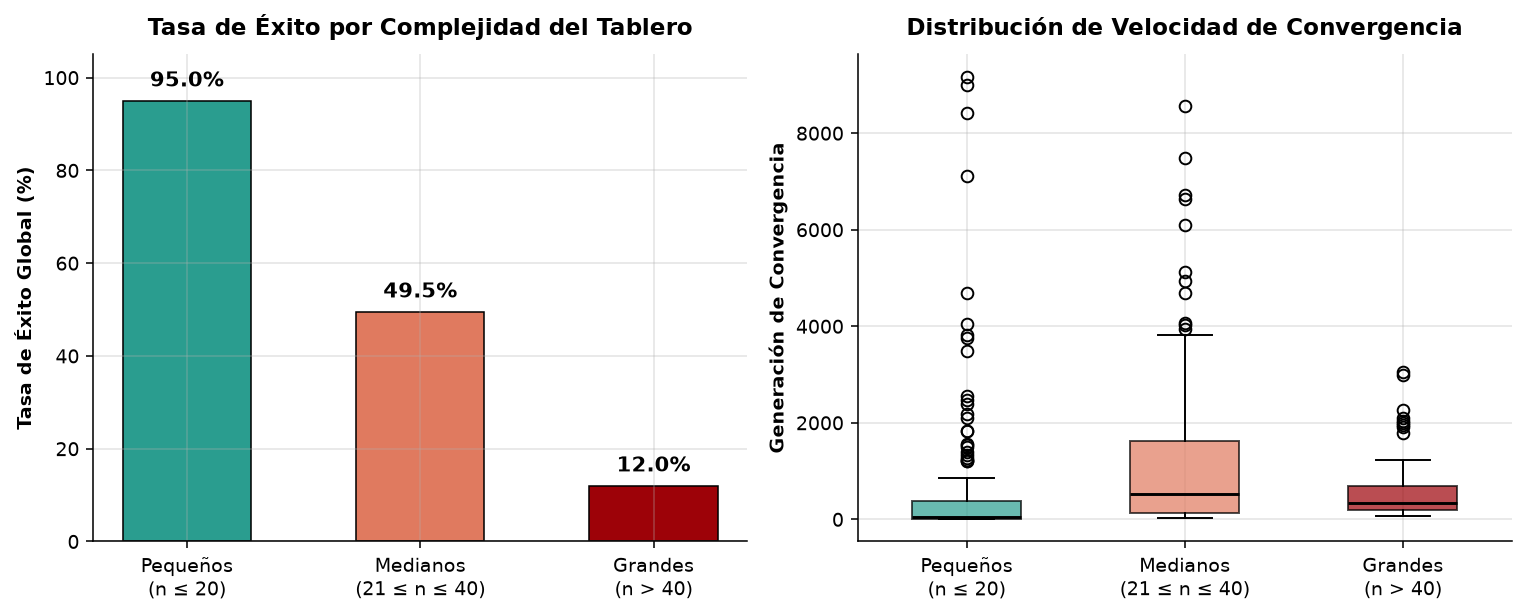

In [35]:
categorias = ['Pequeños\n(n ≤ 20)', 'Medianos\n(21 ≤ n ≤ 40)', 'Grandes\n(n > 40)']
tasas = [
    sum(1 for r in cat_peq if r['exito']) / len(cat_peq) * 100,
    sum(1 for r in cat_med if r['exito']) / len(cat_med) * 100,
    sum(1 for r in cat_gra if r['exito']) / len(cat_gra) * 100
]
gens_peq = [r['generacion_encontrada'] for r in cat_peq if r['exito']]
gens_med = [r['generacion_encontrada'] for r in cat_med if r['exito']]
gens_gra = [r['generacion_encontrada'] for r in cat_gra if r['exito']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel 1: Barras de éxito
bars = ax1.bar(categorias, tasas, color=[C_TEAL, C_ORANGE, C_RED], width=0.55, edgecolor='black', linewidth=0.8)
for b in bars:
    y = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, y + 2, f'{y:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_ylim(0, 105)
ax1.set_ylabel('Tasa de Éxito Global (%)', fontweight='bold')
ax1.set_title('Tasa de Éxito por Complejidad del Tablero', fontweight='bold', pad=10)

# Panel 2: Boxplot de generaciones
bp = ax2.boxplot([gens_peq, gens_med, gens_gra], tick_labels=categorias, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], [C_TEAL, C_ORANGE, C_RED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Generación de Convergencia', fontweight='bold')
ax2.set_title('Distribución de Velocidad de Convergencia', fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('figures/tasa_exito_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Paisaje Global de Parámetros: Mapa de Calor 2D ($N$ vs $\mu$)

El mapa de calor representa en dos dimensiones el comportamiento de convergencia:
- Cada fila representa un tamaño de tablero ($N$).
- Cada columna representa una tasa de mutación ($\mu \in [0.001, 0.20]$).
- El color indica la generación en la que se halló la solución libre de colisiones (los colores más oscuros/verdes indican mayor rapidez).
- Las celdas en gris claro señalan combinaciones donde el algoritmo agotó el límite de generaciones sin alcanzar 0 colisiones.


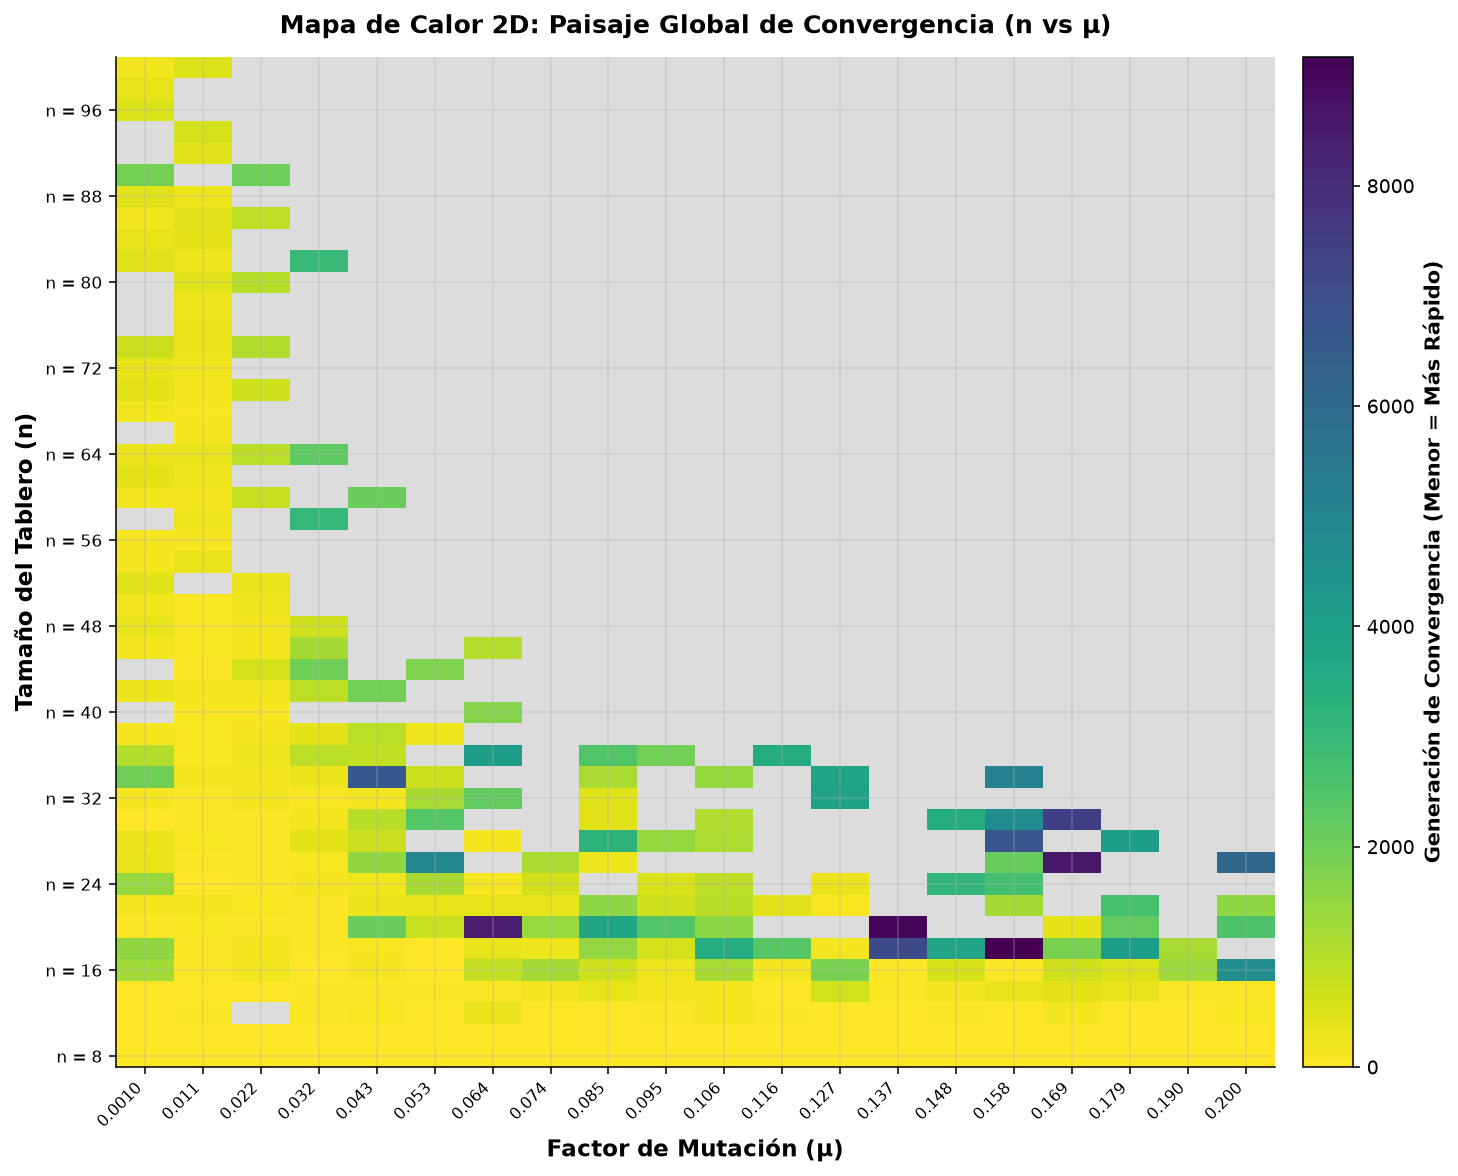

In [36]:
grid_board = np.full((len(n_unicos_b), len(mut_unicas_b)), np.nan)
for r in board_results:
    i = n_unicos_b.index(r['n'])
    j = mut_unicas_b.index(round(r['mutacion'], 6))
    if r['generacion_encontrada'] is not None:
        grid_board[i, j] = r['generacion_encontrada']

fig, ax = plt.subplots(figsize=(11, 8.5))
cmap_hm = plt.cm.viridis_r.copy()
cmap_hm.set_bad(color='#dcdcdc')

masked_grid = np.ma.masked_invalid(grid_board)
im = ax.imshow(masked_grid, cmap=cmap_hm, aspect='auto', origin='lower')

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Generación de Convergencia (Menor = Más Rápido)', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(mut_unicas_b)))
ax.set_xticklabels([f'{m:.3f}' if m >= 0.01 else f'{m:.4f}' for m in mut_unicas_b], rotation=45, ha='right', fontsize=8)

y_ticks = range(0, len(n_unicos_b), 4)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'n = {n_unicos_b[i]}' for i in y_ticks], fontsize=8.5)

ax.set_xlabel('Factor de Mutación (μ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Tamaño del Tablero (n)', fontsize=12, fontweight='bold')
ax.set_title('Mapa de Calor 2D: Paisaje Global de Convergencia (n vs μ)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('figures/heatmap_8_a_64.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Ley de Escala de la Tasa de Mutación Óptima ($\mu^*$ vs $N$) e Invarianza Genómica

Determinamos cuantitativamente cuál fue la mutación que logró resolver cada dimensión $N$ en el menor número de generaciones.
En nuestro operador de mutación swap gen a gen, el número esperado de intercambios por individuo es:

$$\mathbb{E}[\text{swaps}] = N \times \mu$$

Al graficar $\mathbb{E}[\text{swaps}]$ para los tableros evaluados, se constata empíricamente que para $N \ge 20$ el valor se mantiene constante alrededor de **$\approx 0.62$ swaps por individuo**.
Esto explica por qué la mutación óptima decae hiperbólicamente conforme $N$ crece ($\mu^*(N) \approx 0.6 / N$): tasas más elevadas en tableros grandes provocan demasiadas perturbaciones simultáneas que destruyen los bloques constructivos de PMX.


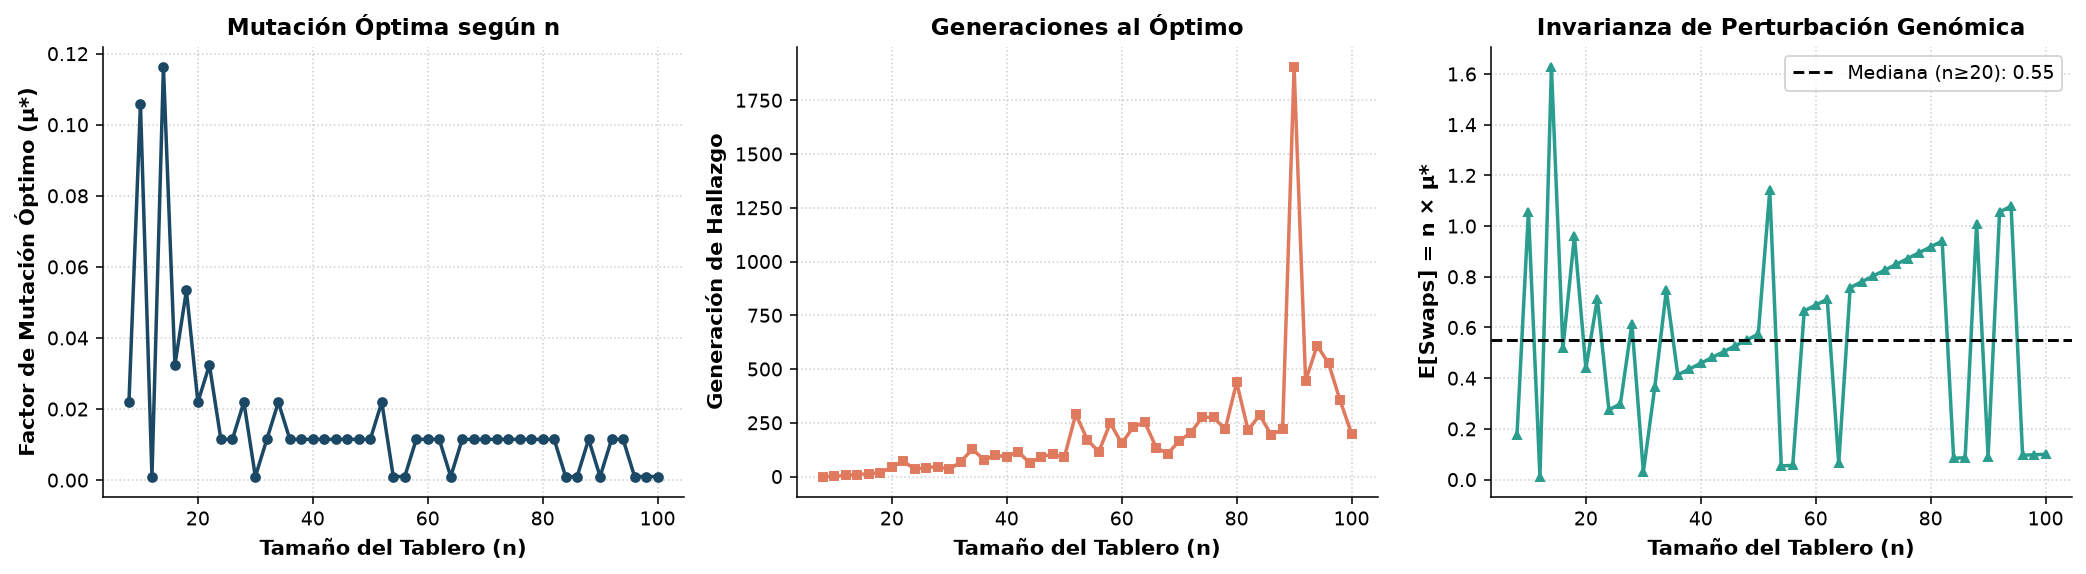

In [37]:
optimos = []
for n in n_unicos_b:
    sub = [r for r in board_results if r['n'] == n]
    exitos = [r for r in sub if r['exito']]
    if exitos:
        best = sorted(exitos, key=lambda r: r['generacion_encontrada'])[0]
        optimos.append({
            'n': n,
            'best_mut': best['mutacion'],
            'best_gen': best['generacion_encontrada'],
            'tiempo': best['tiempo_s'],
            'expected_swaps': n * best['mutacion'],
        })

n_arr = np.array([o['n'] for o in optimos])
mut_arr = np.array([o['best_mut'] for o in optimos])
gen_arr = np.array([o['best_gen'] for o in optimos])
swaps_arr = np.array([o['expected_swaps'] for o in optimos])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))

# 1. Mutación óptima vs n
ax1.plot(n_arr, mut_arr, marker='o', color=C_NAVY, lw=1.8, markersize=4.5)
ax1.set_xlabel('Tamaño del Tablero (n)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Factor de Mutación Óptimo (μ*)', fontsize=11, fontweight='bold')
ax1.set_title('Mutación Óptima según n', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Generaciones requeridas
ax2.plot(n_arr, gen_arr, marker='s', color=C_ORANGE, lw=1.8, markersize=4.5)
ax2.set_xlabel('Tamaño del Tablero (n)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Generación de Hallazgo', fontsize=11, fontweight='bold')
ax2.set_title('Generaciones al Óptimo', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# 3. Intercambios esperados: n * mut
mediana_swaps = np.median(swaps_arr[n_arr >= 20])
ax3.plot(n_arr, swaps_arr, marker='^', color=C_TEAL, lw=1.8, markersize=4.5)
ax3.axhline(mediana_swaps, color='black', linestyle='--', label=f'Mediana (n≥20): {mediana_swaps:.2f}')
ax3.set_xlabel('Tamaño del Tablero (n)', fontsize=11, fontweight='bold')
ax3.set_ylabel('E[Swaps] = n × μ*', fontsize=11, fontweight='bold')
ax3.set_title('Invarianza de Perturbación Genómica', fontsize=12, fontweight='bold')
ax3.legend(frameon=True)
ax3.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('figures/mutacion_optima_vs_n_8_a_64.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Dinámica Generacional del Fitness y Reducción de Colisiones

Visualizamos la evolución del fitness (mejor individuo y promedio poblacional) junto a la curva de colisiones diagonales para tableros representativos ($N = 8, 16, 32, 48, 64$).
Se observa con claridad el **comportamiento bifásico universal**:
1. **Fase macroscópica rápida:** Durante las primeras 20 a 50 generaciones, el cruce PMX combina eficientemente las sub-permutaciones no conflictivas, eliminando más del 80% de los conflictos.
2. **Fase asintótica de afinamiento fino:** Cuando restan menos de 3 conflictos, el elitismo actúa como filtro estricto y la mutación puntual desacopla las últimas diagonales en colisión.


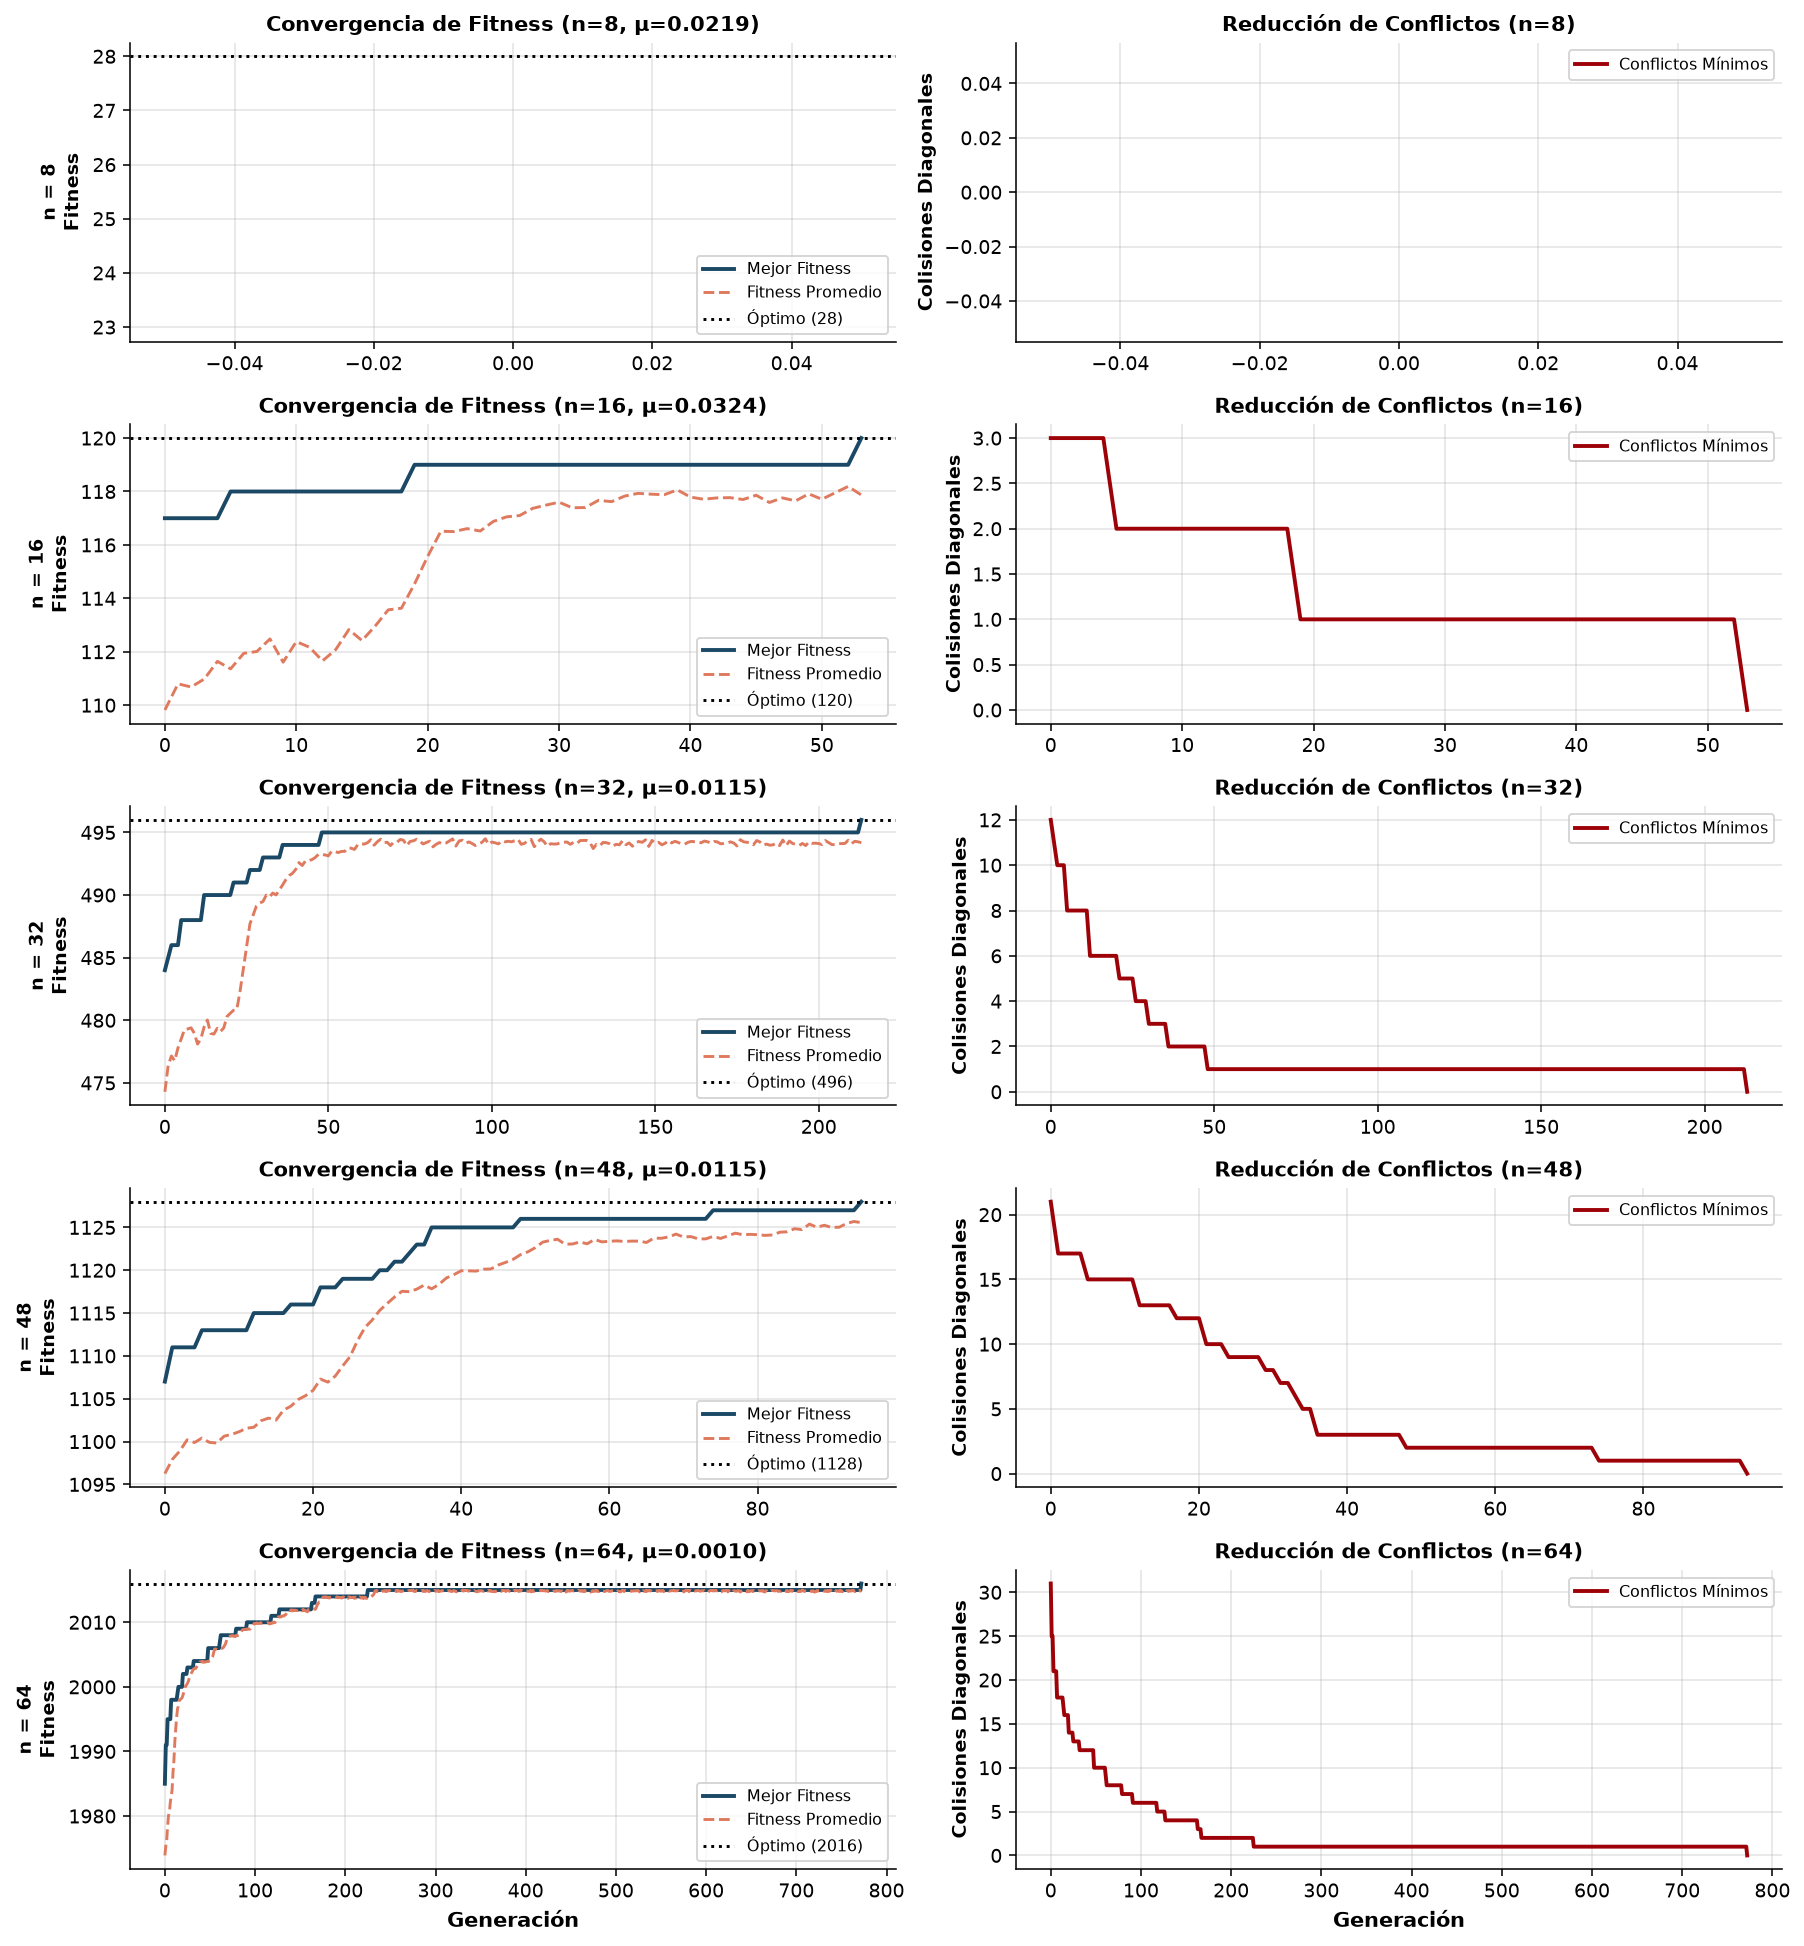

In [38]:
tableros_rep = [8, 16, 32, 48, 64]
fig, axes = plt.subplots(len(tableros_rep), 2, figsize=(13, 2.8 * len(tableros_rep)), sharex=False)

for idx, n_target in enumerate(tableros_rep):
    ax_fit = axes[idx, 0]
    ax_conf = axes[idx, 1]
    
    sub_runs = [r for r in board_results if r['n'] == n_target and r['exito']]
    if sub_runs:
        best_run = sorted(sub_runs, key=lambda r: r['generacion_encontrada'])[0]
        mut_sel = best_run['mutacion']
    else:
        mut_sel = 0.0115
        
    key = f'n_{n_target}_mut_{mut_sel:.4f}'
    if key in board_metrics:
        gens_info = board_metrics[key]['generations']
        x = [g['generation'] for g in gens_info]
        best_f = [g['best_fitness'] for g in gens_info]
        mean_f = [g['mean_fitness'] for g in gens_info]
        conflicts = [g['best_conflicts'] for g in gens_info]
        max_f = (n_target * (n_target - 1)) // 2
        
        # Panel izquierdo: Fitness
        ax_fit.plot(x, best_f, color=C_NAVY, lw=2, label='Mejor Fitness')
        ax_fit.plot(x, mean_f, color=C_ORANGE, lw=1.5, linestyle='--', label='Fitness Promedio')
        ax_fit.axhline(max_f, color='black', linestyle=':', label=f'Óptimo ({max_f})')
        ax_fit.set_ylabel(f'n = {n_target}\nFitness', fontsize=10, fontweight='bold')
        ax_fit.set_title(f'Convergencia de Fitness (n={n_target}, μ={mut_sel:.4f})', fontsize=11, fontweight='bold')
        ax_fit.legend(loc='lower right', fontsize=8)
        
        # Panel derecho: Conflictos
        ax_conf.plot(x, conflicts, color=C_RED, lw=2, label='Conflictos Mínimos')
        ax_conf.set_ylabel('Colisiones Diagonales', fontsize=10, fontweight='bold')
        ax_conf.set_title(f'Reducción de Conflictos (n={n_target})', fontsize=11, fontweight='bold')
        ax_conf.legend(loc='upper right', fontsize=8)

axes[-1, 0].set_xlabel('Generación', fontsize=11, fontweight='bold')
axes[-1, 1].set_xlabel('Generación', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/variacion_fitness.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Variación por Tamaño de Población ($M \in [20, 500]$ para $N=25$)

En esta sección abordamos el segundo eje maestro del análisis: ¿Cómo influye el tamaño de la población $M$ en la capacidad de búsqueda global del algoritmo genético?
Para aislar el efecto de la población, mantenemos fijas las dimensiones del problema en $N=25$ reinas ($25! \approx 1.55 \times 10^{25}$) y variamos la población en 49 valores discretos ($M \in [20, 500]$ con paso 10), evaluando para cada uno 20 factores de mutación (total de **980 experimentos**).

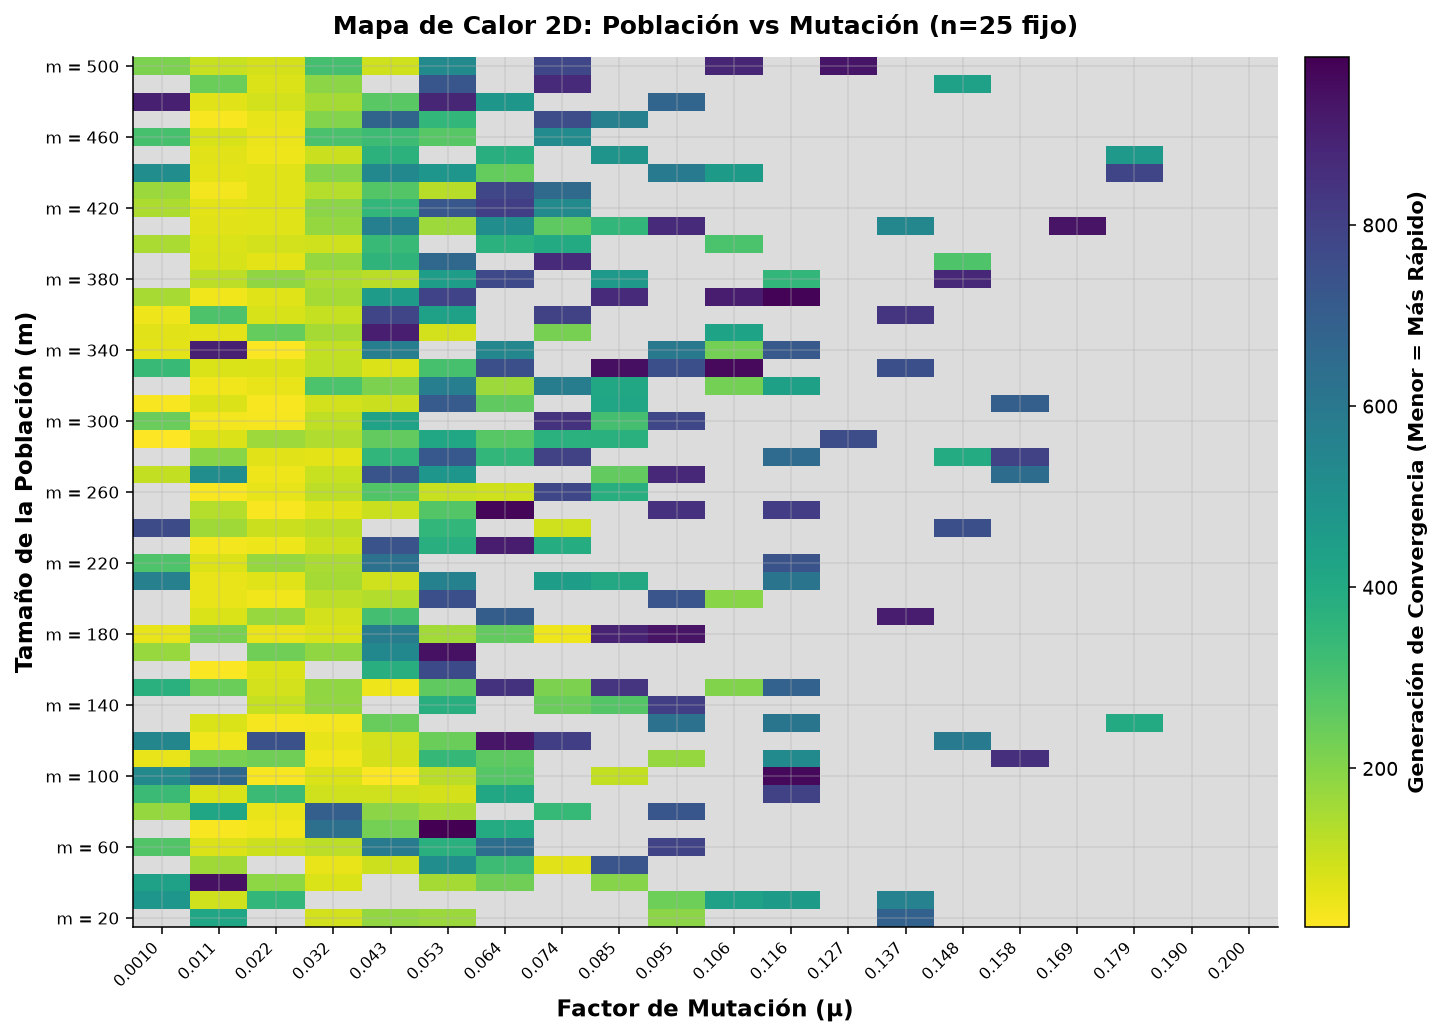

In [39]:
grid_pop = np.full((len(pops_unicos_p), len(mut_unicas_p)), np.nan)
for r in pop_results:
    i = pops_unicos_p.index(r['poblacion'])
    j = mut_unicas_p.index(round(r['mutacion'], 6))
    if r['generacion_encontrada'] is not None:
        grid_pop[i, j] = r['generacion_encontrada']

fig, ax = plt.subplots(figsize=(11, 7.5))
masked_grid_pop = np.ma.masked_invalid(grid_pop)
im_pop = ax.imshow(masked_grid_pop, cmap=cmap_hm, aspect='auto', origin='lower')

cbar_pop = fig.colorbar(im_pop, ax=ax, pad=0.02)
cbar_pop.set_label('Generación de Convergencia (Menor = Más Rápido)', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(mut_unicas_p)))
ax.set_xticklabels([f'{m:.3f}' if m >= 0.01 else f'{m:.4f}' for m in mut_unicas_p], rotation=45, ha='right', fontsize=8)

y_ticks_pop = range(0, len(pops_unicos_p), 4)
ax.set_yticks(y_ticks_pop)
ax.set_yticklabels([f'm = {pops_unicos_p[i]}' for i in y_ticks_pop], fontsize=8.5)

ax.set_xlabel('Factor de Mutación (μ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Tamaño de la Población (m)', fontsize=12, fontweight='bold')
ax.set_title('Mapa de Calor 2D: Población vs Mutación (n=25 fijo)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('figures/heatmap_poblacion_vs_mutacion.png', dpi=150, bbox_inches='tight')
plt.show()


### Compromiso de Eficiencia Computacional (Trade-Off) y Umbral de Viabilidad

El análisis conjunto de la tasa de éxito y el tiempo de cómputo revela dos hallazgos teóricos y prácticos clave:

1. **Umbral Crítico de Diversidad Alélica ($M \approx 60$):** Poblaciones por debajo de 60 individuos sufren una drástica reducción en la tasa de éxito y estancamiento recurrente en óptimos locales (1 o 2 colisiones). La reserva genética es insuficiente para permitir recombinaciones constructivas en PMX.
2. **Ley de Rendimientos Decrecientes en Tiempo de CPU:** Aumentar la población más allá de $M \approx 150\text{--}200$ apenas reduce las generaciones necesarias para converger, pero dispara linealmente el tiempo de cómputo total (cada ciclo poblacional requiere evaluar $M$ individuos con chequeo diagonal en $O(N)$). El **punto dulce de eficiencia** para $N=25$ se ubica en $M \in [100, 200]$.

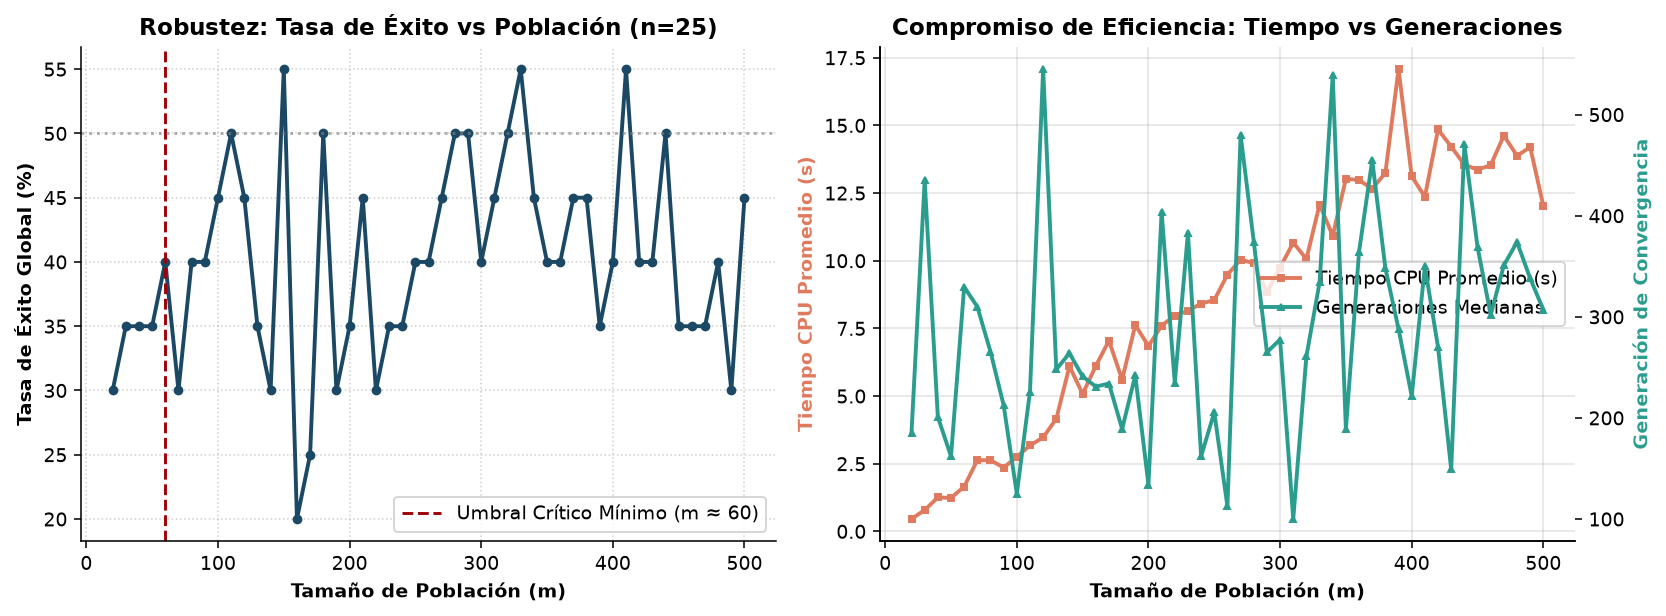

In [40]:
pop_stats = []
for p in pops_unicos_p:
    sub = [r for r in pop_results if r['poblacion'] == p]
    ex = [r for r in sub if r['exito']]
    gens = [r['generacion_encontrada'] for r in ex] if ex else []
    times = [r['tiempo_s'] for r in sub]
    pop_stats.append({
        'pop': p,
        'tasa_exito': len(ex) / len(sub) * 100,
        'gen_mediana': np.median(gens) if gens else np.nan,
        'tiempo_prom': np.mean(times)
    })

p_arr = np.array([s['pop'] for s in pop_stats])
tasa_arr = np.array([s['tasa_exito'] for s in pop_stats])
t_arr = np.array([s['tiempo_prom'] for s in pop_stats])
g_arr = np.array([s['gen_mediana'] for s in pop_stats])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: Tasa de éxito vs m
ax1.plot(p_arr, tasa_arr, marker='o', color=C_NAVY, lw=2, markersize=4)
ax1.axvline(60, color=C_RED, linestyle='--', label='Umbral Crítico Mínimo (m ≈ 60)')
ax1.axhline(50, color='gray', linestyle=':', alpha=0.6)
ax1.set_xlabel('Tamaño de Población (m)', fontweight='bold')
ax1.set_ylabel('Tasa de Éxito Global (%)', fontweight='bold')
ax1.set_title('Robustez: Tasa de Éxito vs Población (n=25)', fontweight='bold')
ax1.legend(frameon=True, loc='lower right')
ax1.grid(True, linestyle=':', alpha=0.6)

# Panel 2: Trade-off tiempo vs generaciones
ax2_twin = ax2.twinx()
ax2_twin.grid(False)

l1 = ax2.plot(p_arr, t_arr, color=C_ORANGE, lw=2, marker='s', markersize=3.5, label='Tiempo CPU Promedio (s)')
l2 = ax2_twin.plot(p_arr, g_arr, color=C_TEAL, lw=2, marker='^', markersize=3.5, label='Generaciones Medianas')

ax2.set_xlabel('Tamaño de Población (m)', fontweight='bold')
ax2.set_ylabel('Tiempo CPU Promedio (s)', color=C_ORANGE, fontweight='bold')
ax2_twin.set_ylabel('Generación de Convergencia', color=C_TEAL, fontweight='bold')
ax2.set_title('Compromiso de Eficiencia: Tiempo vs Generaciones', fontweight='bold')

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='center right', frameon=True)

plt.tight_layout()
plt.savefig('figures/poblacion_vs_exito_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()


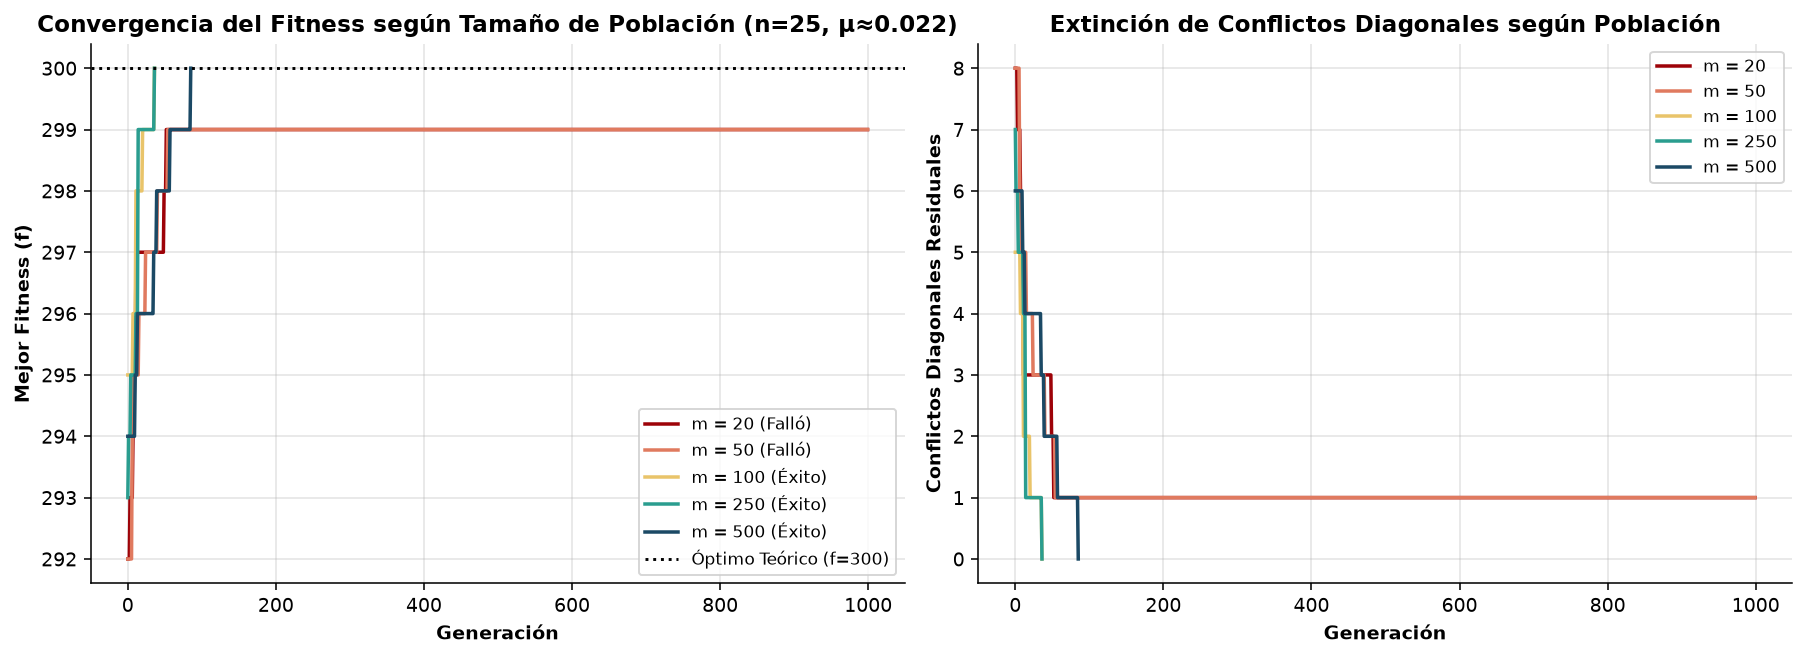

In [41]:
with open('data/multi_metrics_population.json', 'r', encoding='utf-8') as f:
    pop_metrics = json.load(f)

pops_to_plot = [20, 50, 100, 250, 500]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
colors = [C_RED, C_ORANGE, '#e9c46a', C_TEAL, C_NAVY]

for p, col in zip(pops_to_plot, colors):
    matching_keys = [k for k in pop_metrics.keys() if f'pop_{p}_' in k and '0.0219' in k]
    if not matching_keys:
        matching_keys = [k for k in pop_metrics.keys() if f'pop_{p}_' in k and '0.0115' in k]
    if matching_keys:
        k = matching_keys[0]
        gens = pop_metrics[k]['generations']
        x = [g['generation'] for g in gens]
        bf = [g['best_fitness'] for g in gens]
        conf = [g['best_conflicts'] for g in gens]
        optimo_str = " (Éxito)" if pop_metrics[k]['summary']['optimo_encontrado'] else " (Falló)"
        
        ax1.plot(x, bf, label=f'm = {p}{optimo_str}', color=col, lw=1.8)
        ax2.plot(x, conf, label=f'm = {p}', color=col, lw=1.8)

ax1.axhline(300, color='black', linestyle=':', label='Óptimo Teórico (f=300)')
ax1.set_xlabel('Generación', fontweight='bold')
ax1.set_ylabel('Mejor Fitness (f)', fontweight='bold')
ax1.set_title('Convergencia del Fitness según Tamaño de Población (n=25, μ≈0.022)', fontweight='bold')
ax1.legend(loc='lower right', fontsize=8.5, frameon=True)

ax2.set_xlabel('Generación', fontweight='bold')
ax2.set_ylabel('Conflictos Diagonales Residuales', fontweight='bold')
ax2.set_title('Extinción de Conflictos Diagonales según Población', fontweight='bold')
ax2.legend(loc='upper right', fontsize=8.5, frameon=True)

plt.tight_layout()
plt.savefig('figures/variacion_fitness_poblacion.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Renderizado Visual del Fenotipo: Tableros de Ajedrez ($N$-Reinas)

Para inspeccionar las soluciones óptimas alcanzadas en el espacio fenotípico, representamos los cromosomas sobre tableros de ajedrez reales.
- Las casillas alternan colores claros y oscuros.
- Las reinas se representan mediante coronas `♛`.
- Las reinas libres de conflicto diagonal se muestran en color azul marino (`#1b4965`), mientras que las reinas en conflicto mutuo se destacarían en color rojo carmesí (`#c1121f`).


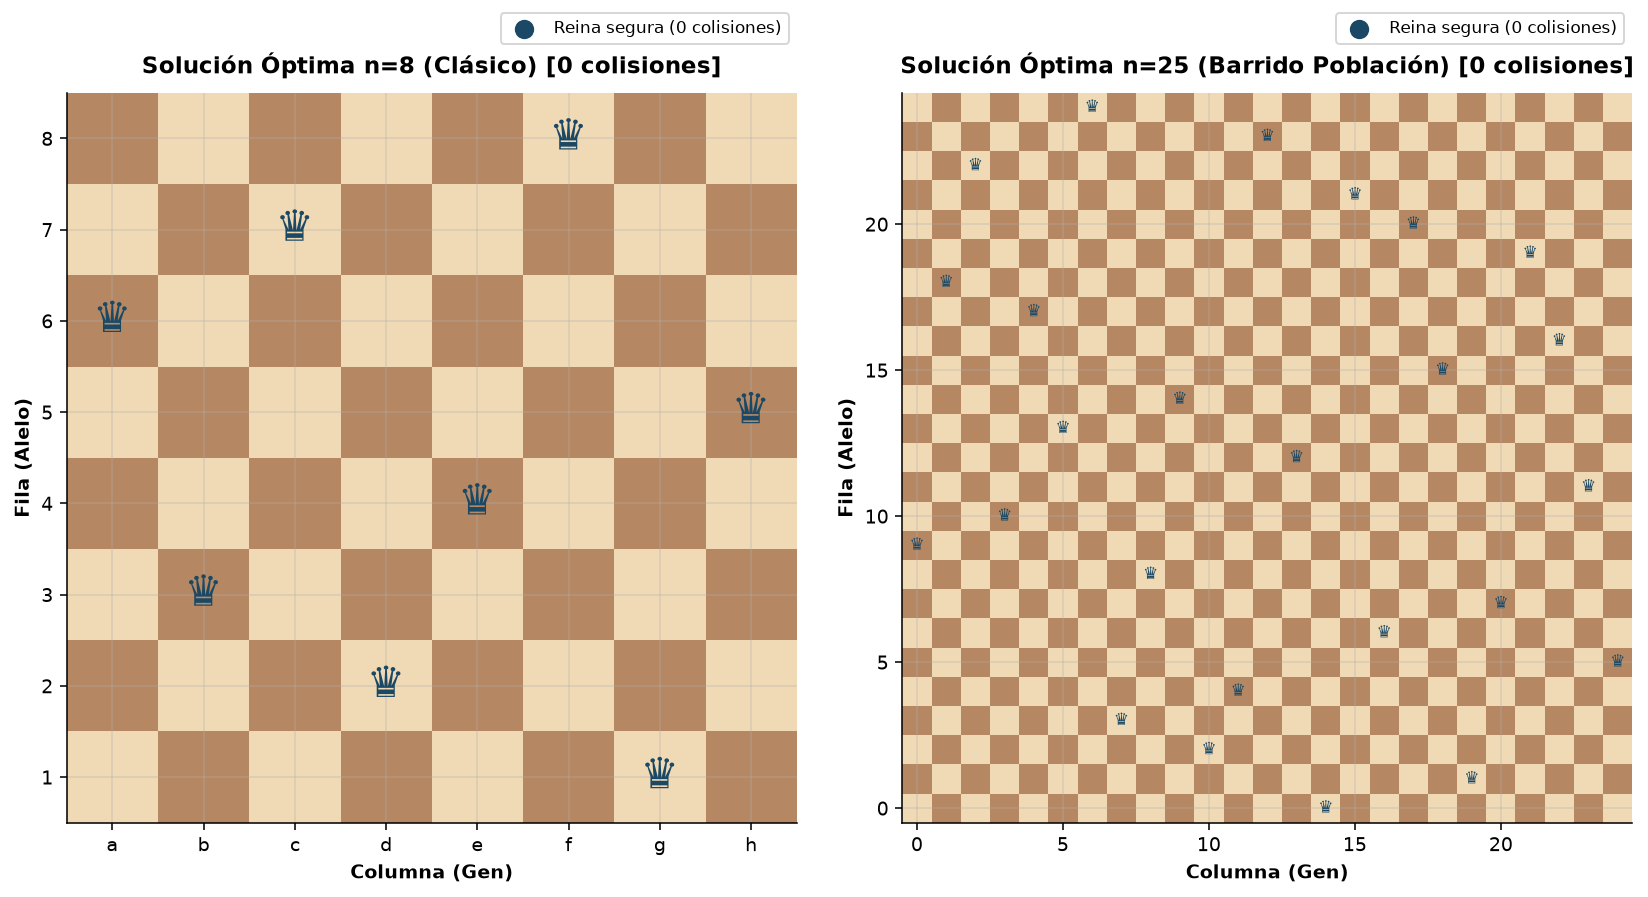

In [42]:
def conflict_positions(state):
    state = list(state)
    pos, neg = {}, {}
    for col, fil in enumerate(state):
        pos.setdefault(fil + col, []).append(col)
        neg.setdefault(fil - col, []).append(col)
    malas = set()
    for grupo in (*pos.values(), *neg.values()):
        if len(grupo) > 1:
            malas.update(grupo)
    return sorted(malas)

# Extraer soluciones óptimas reales de disco
state_8 = None
state_25 = None

if os.path.isfile('data/multi_data_board.json'):
    with open('data/multi_data_board.json') as f:
        db = json.load(f)
        for k, v in db.items():
            if v.get('optimo_encontrado') and v['n'] == 8 and state_8 is None:
                state_8 = v['best_solution']

if os.path.isfile('data/multi_data_population.json'):
    with open('data/multi_data_population.json') as f:
        dp = json.load(f)
        for k, v in dp.items():
            if v.get('optimo_encontrado') and state_25 is None:
                state_25 = v['best_solution']

if state_8 is None: state_8 = [3, 5, 7, 1, 6, 0, 2, 4]
if state_25 is None: state_25 = list(range(25))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, state, titulo in zip(axes, [state_8, state_25], ['Solución Óptima n=8 (Clásico)', 'Solución Óptima n=25 (Barrido Población)']):
    n = len(state)
    malas = set(conflict_positions(state))
    cols = np.arange(n)
    rows = np.array(state)
    ok = np.array([c not in malas for c in cols])
    
    board = (np.indices((n, n)).sum(axis=0) % 2)
    cmap_board = ListedColormap(['#f0d9b5', '#b58863'])
    ax.imshow(board, cmap=cmap_board, origin='lower', extent=(-0.5, n - 0.5, -0.5, n - 0.5), zorder=0)
    
    queen_size = max(6, min(22, 220 / n))
    for col, row, is_ok in zip(cols, rows, ok):
        color = C_NAVY if is_ok else C_RED
        ax.text(col, row, '♛', ha='center', va='center', fontsize=queen_size, color=color, fontweight='bold', zorder=3)
        
    ax.scatter([], [], s=80, color=C_NAVY, label='Reina segura (0 colisiones)')
    if (~ok).any():
        ax.scatter([], [], s=80, color=C_RED, label='Reina en conflicto')
        
    if n <= 16:
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        if n == 8:
            ax.set_xticklabels([chr(ord('a') + i) for i in range(n)])
            ax.set_yticklabels(range(1, n + 1))
    else:
        step = max(1, n // 5)
        ax.set_xticks(np.arange(0, n, step))
        ax.set_yticks(np.arange(0, n, step))
        
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Columna (Gen)', fontweight='bold')
    ax.set_ylabel('Fila (Alelo)', fontweight='bold')
    ax.set_title(f'{titulo} [{len(malas)} colisiones]', fontweight='bold', pad=10)
    ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.12), fontsize=8.5, frameon=True)

plt.tight_layout()
plt.savefig('figures/tableros_solucion_ejemplos.png', dpi=150, bbox_inches='tight')
plt.show()
